# Final Evaluation

This notebook pulls the final results together.

## Purpose

Collect the forecasting, baseline, optimisation, rolling-control and explanation results into final tables and figures.

In [1]:
from pathlib import Path
import json
import math
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


def find_project_root(start: Path | None = None) -> Path:
    """Find the repository root from either the root or Notebooks directory."""
    current = Path(start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "Data").exists() and (candidate / "Notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing Data/ and Notebooks/.")


ROOT = find_project_root()
DATA_DIR = ROOT / "Data"
RESULTS_DIR = DATA_DIR / "Results"
PROCESSED_DIR = DATA_DIR / "Processed"
FIGURES_DIR = ROOT / "Figures"
MODELS_DIR = ROOT / "Models" / "Forecasting"

for directory in [RESULTS_DIR, PROCESSED_DIR, FIGURES_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

INTERVAL_MINUTES = 5
INTERVAL_HOURS = INTERVAL_MINUTES / 60
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

print(f"Project root: {ROOT}")

Project root: /Users/mac/Send-Ev-Project/SEND-EV-Project


In [2]:
def save_table(df: pd.DataFrame, path: Path) -> Path:
    """Save Parquet where available, otherwise save CSV with the same stem."""
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.suffix.lower() == ".parquet":
        try:
            df.to_parquet(path, index=False)
            print(f"Saved: {path.relative_to(ROOT)}")
            return path
        except (ImportError, ModuleNotFoundError) as exc:
            csv_path = path.with_suffix(".csv")
            df.to_csv(csv_path, index=False)
            print(f"Parquet engine unavailable ({exc.__class__.__name__}); saved CSV: {csv_path.relative_to(ROOT)}")
            return csv_path
    df.to_csv(path, index=False)
    print(f"Saved: {path.relative_to(ROOT)}")
    return path


def read_table(path: Path, parse_dates: list[str] | None = None) -> pd.DataFrame:
    """Read a Parquet/CSV output regardless of which format was written."""
    candidates = [path]
    if path.suffix.lower() == ".parquet":
        candidates.append(path.with_suffix(".csv"))
    elif path.suffix.lower() == ".csv":
        candidates.append(path.with_suffix(".parquet"))

    parquet_error: Exception | None = None

    for candidate in candidates:
        if candidate.exists():
            if candidate.suffix.lower() == ".parquet":
                try:
                    return pd.read_parquet(candidate)
                except (ImportError, ModuleNotFoundError) as exc:
                    parquet_error = exc
                    continue
            return pd.read_csv(candidate, parse_dates=parse_dates)

    if parquet_error is not None:
        raise ImportError(
            "A Parquet file exists, but pandas cannot read it and no CSV fallback was found. "
            "Install pyarrow or fastparquet, or rerun the previous notebook to create the CSV fallback."
        ) from parquet_error

    raise FileNotFoundError(f"None of these files exists: {candidates}")

## 1. Load available result files

In [3]:
def optional_csv(path: Path) -> pd.DataFrame:
    if path.exists():
        frame = pd.read_csv(path)
        print(f"Loaded {path.name}: {len(frame):,} rows")
        return frame
    print(f"Not available yet: {path.name}")
    return pd.DataFrame()


baseline_metrics = optional_csv(RESULTS_DIR / "baseline_metrics.csv")
optimisation_metrics = optional_csv(RESULTS_DIR / "optimisation_metrics.csv")
rolling_metrics = optional_csv(RESULTS_DIR / "rolling_horizon_metrics.csv")
counterfactual_metrics = optional_csv(RESULTS_DIR / "counterfactual_metrics.csv")
shap_importance = optional_csv(RESULTS_DIR / "shap_feature_importance.csv")

operational_frames = [f for f in [baseline_metrics, optimisation_metrics, rolling_metrics] if not f.empty]
if not operational_frames:
    raise FileNotFoundError("Run notebooks 13-15 before the final evaluation.")

operational = pd.concat(operational_frames, ignore_index=True, sort=False)
print("Strategies:", operational["strategy"].drop_duplicates().tolist())

Loaded baseline_metrics.csv: 48 rows
Loaded optimisation_metrics.csv: 24 rows
Loaded rolling_horizon_metrics.csv: 6 rows
Loaded counterfactual_metrics.csv: 1 rows
Loaded shap_feature_importance.csv: 42 rows
Strategies: ['immediate', 'fixed_delayed', 'optimised_actual', 'rolling_actual']


## 2. Strategy summary

In [4]:
METRICS = [
    "service_rate",
    "renewable_absorbed_kwh",
    "residual_surplus_kwh",
    "ev_grid_energy_kwh",
    "unserved_energy_kwh",
    "peak_ev_kw",
    "peak_total_load_kw",
]
metrics_available = [m for m in METRICS if m in operational.columns]

summary = (
    operational.groupby(["strategy", "forecast_source"], dropna=False)[metrics_available]
    .agg(["count", "mean", "std", "median"])
)
display(summary)
summary.to_csv(RESULTS_DIR / "final_strategy_summary.csv")

service_rate                          renewable_absorbed_kwh                                     residual_surplus_kwh  \
                                        count      mean     std median                  count        mean         std      median                count   
strategy         forecast_source                                                                                                                         
fixed_delayed    none                      24  0.981433  0.0314    1.0                     24  159.460127  153.035295   94.503333                   24   
immediate        none                      24  1.000000  0.0000    1.0                     24  136.034664  131.724993   82.046667                   24   
optimised_actual actual                    24  1.000000  0.0000    1.0                     24  584.140466  465.566655  449.445202                   24   
rolling_actual   actual                     6  1.000000  0.0000    1.0                      6   37.377407   20.510461   33.796667                    6   

                                                                         ev_grid_energy_kwh                                  unserved_energy_kwh            \
                                          mean         std        median              count       mean        std     median               count      mean   
strategy         forecast_source                                                                                                                             
fixed_delayed    none             12536.144298  161.061496  12614.151311                 24  35.096308  29.612717  36.850000                  24  0.097667   
immediate        none             12559.569761  144.092998  12622.689089                 24  58.702975  48.629390  45.387778                  24  0.000000   
optimised_actual actual           12111.463959  451.658194  12252.725350                 24  32.483762  28.697132  36.850000                  24  0.000000   
rolling_actual   actual           12603.593025  169.071205  12670.876311                  6  15.876667  16.946094  10.780000                   6  0.000000   

                                                  peak_ev_kw                              peak_total_load_kw                                       
                                       std median      count       mean        std median              count         mean        std       median  
strategy         forecast_source                                                                                                                   
fixed_delayed    none             0.141092    0.0         24  73.000000  58.171702  53.42                 24  2102.917875  51.979104  2077.853667  
immediate        none             0.000000    0.0         24  38.600556  30.967727  29.70                 24  2088.829000  25.707912  2081.954000  
optimised_actual actual           0.000000    0.0         24  80.274995  56.999151  66.00                 24  2130.295120  55.261077  2116.807000  
rolling_actual   actual           0.000000    0.0          6  15.399999   3.408226  13.20                  6  2067.653999   4.968299  2068.753999

## 3. Improvements relative to immediate charging

In [5]:
baseline_reference = operational[operational["strategy"].eq("immediate")][
    ["scenario_id", *metrics_available]
].copy()
baseline_reference = baseline_reference.rename(columns={m: f"baseline_{m}" for m in metrics_available})

comparison = operational.merge(baseline_reference, on="scenario_id", how="left")
if "renewable_absorbed_kwh" in comparison:
    comparison["renewable_absorption_change_kwh"] = (
        comparison["renewable_absorbed_kwh"] - comparison["baseline_renewable_absorbed_kwh"]
    )
if "residual_surplus_kwh" in comparison:
    comparison["residual_surplus_reduction_kwh"] = (
        comparison["baseline_residual_surplus_kwh"] - comparison["residual_surplus_kwh"]
    )
if "ev_grid_energy_kwh" in comparison:
    comparison["grid_energy_change_kwh"] = (
        comparison["ev_grid_energy_kwh"] - comparison["baseline_ev_grid_energy_kwh"]
    )
if "service_rate" in comparison:
    comparison["service_rate_change"] = comparison["service_rate"] - comparison["baseline_service_rate"]

change_columns = [
    c for c in [
        "renewable_absorption_change_kwh", "residual_surplus_reduction_kwh",
        "grid_energy_change_kwh", "service_rate_change"
    ] if c in comparison.columns
]
change_summary = comparison.groupby("strategy")[change_columns].agg(["mean", "std", "median"])
display(change_summary)
save_table(comparison, RESULTS_DIR / "final_model_comparison.csv")

renewable_absorption_change_kwh                         residual_surplus_reduction_kwh                         grid_energy_change_kwh  \
                                            mean         std      median                           mean         std      median                   mean   
strategy                                                                                                                                                 
fixed_delayed                          23.425463   21.942965   14.450556                      23.425463   21.942965   14.450556             -23.606667   
immediate                               0.000000    0.000000    0.000000                       0.000000    0.000000    0.000000               0.000000   
optimised_actual                      448.105802  338.006056  367.398535                     448.105802  338.006056  367.398535             -26.219213   
rolling_actual                          5.822963    4.872623    7.150000                       5.822963    4.872623    7.150000              -5.822963   

                                       service_rate_change                 
                        std     median                mean     std median  
strategy                                                                   
fixed_delayed     22.102721 -14.837222           -0.018567  0.0314    0.0  
immediate          0.000000   0.000000            0.000000  0.0000    0.0  
optimised_actual  25.398911 -14.837222            0.000000  0.0000    0.0  
rolling_actual     4.872623  -7.150000            0.000000  0.0000    0.0

Saved: Data/Results/final_model_comparison.csv


PosixPath('/Users/mac/Send-Ev-Project/SEND-EV-Project/Data/Results/final_model_comparison.csv')

## 4. Bootstrap confidence intervals

In [6]:
def bootstrap_mean_ci(values, confidence: float = 0.95, resamples: int = 2_000, seed: int = 42):
    values = pd.Series(values).dropna().to_numpy(dtype=float)
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    local_rng = np.random.default_rng(seed)
    means = np.empty(resamples)
    for i in range(resamples):
        means[i] = local_rng.choice(values, size=len(values), replace=True).mean()
    alpha = (1 - confidence) / 2
    return values.mean(), np.quantile(means, alpha), np.quantile(means, 1 - alpha)


ci_rows = []
for strategy, frame in comparison.groupby("strategy"):
    for metric in change_columns:
        mean, lower, upper = bootstrap_mean_ci(frame[metric])
        ci_rows.append({
            "strategy": strategy,
            "metric": metric,
            "mean": mean,
            "ci_lower": lower,
            "ci_upper": upper,
        })
confidence_intervals = pd.DataFrame(ci_rows)
display(confidence_intervals)
save_table(confidence_intervals, RESULTS_DIR / "final_bootstrap_confidence_intervals.csv")

,strategy,metric,mean,ci_lower,ci_upper
0,fixed_delayed,renewable_absorption_change_kwh,23.425463,15.544225,33.112293
1,fixed_delayed,residual_surplus_reduction_kwh,23.425463,15.544225,33.112293
2,fixed_delayed,grid_energy_change_kwh,-23.606667,-33.357869,-15.666669
3,fixed_delayed,service_rate_change,-0.018567,-0.031470,-0.007328
4,immediate,renewable_absorption_change_kwh,0.000000,0.000000,0.000000
5,immediate,residual_surplus_reduction_kwh,0.000000,0.000000,0.000000
6,immediate,grid_energy_change_kwh,0.000000,0.000000,0.000000
7,immediate,service_rate_change,0.000000,0.000000,0.000000
8,optimised_actual,renewable_absorption_change_kwh,448.105802,320.274009,588.767525
9,optimised_actual,residual_surplus_reduction_kwh,448.105802,320.274009,588.767525


Saved: Data/Results/final_bootstrap_confidence_intervals.csv


PosixPath('/Users/mac/Send-Ev-Project/SEND-EV-Project/Data/Results/final_bootstrap_confidence_intervals.csv')

## 5. Sensitivity analysis by fleet size and participation

In [7]:
sensitivity_metrics = [
    c for c in ["renewable_absorption_change_kwh", "residual_surplus_reduction_kwh", "service_rate"]
    if c in comparison.columns
]
if {"fleet_size", "participation_rate"}.issubset(comparison.columns):
    sensitivity = (
        comparison.groupby(["strategy", "fleet_size", "participation_rate"], as_index=False)[sensitivity_metrics]
        .mean()
    )
    display(sensitivity.head(20))
    save_table(sensitivity, RESULTS_DIR / "final_sensitivity_analysis.csv")
else:
    sensitivity = pd.DataFrame()

,strategy,fleet_size,participation_rate,renewable_absorption_change_kwh,residual_surplus_reduction_kwh,service_rate
0,fixed_delayed,10,0.25,0.000000,0.000000,1.000000
1,fixed_delayed,10,0.50,7.150000,7.150000,1.000000
2,fixed_delayed,10,0.75,10.318889,10.318889,1.000000
3,fixed_delayed,10,1.00,10.531667,10.531667,0.950000
4,fixed_delayed,25,0.25,7.150000,7.150000,1.000000
5,fixed_delayed,25,0.50,12.456667,12.456667,0.958333
6,fixed_delayed,25,0.75,32.692222,32.692222,0.973684
7,fixed_delayed,25,1.00,31.486111,31.486111,0.980000
8,fixed_delayed,50,0.25,12.456667,12.456667,0.958333
9,fixed_delayed,50,0.50,33.517222,33.517222,0.980000


Saved: Data/Results/final_sensitivity_analysis.csv


## 6. Dissertation-ready plots

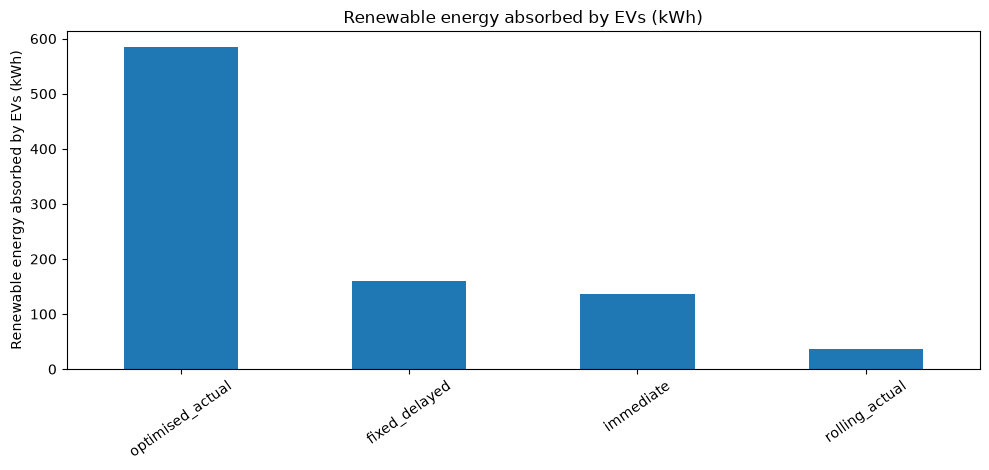

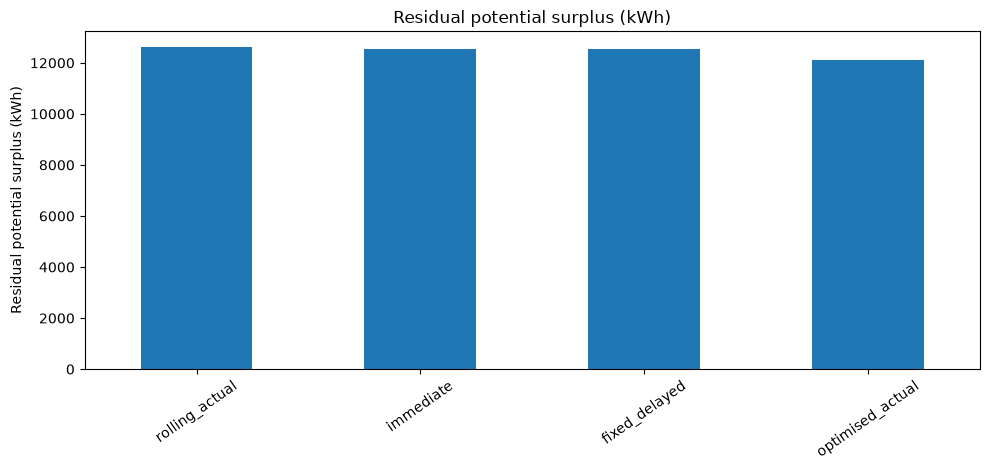

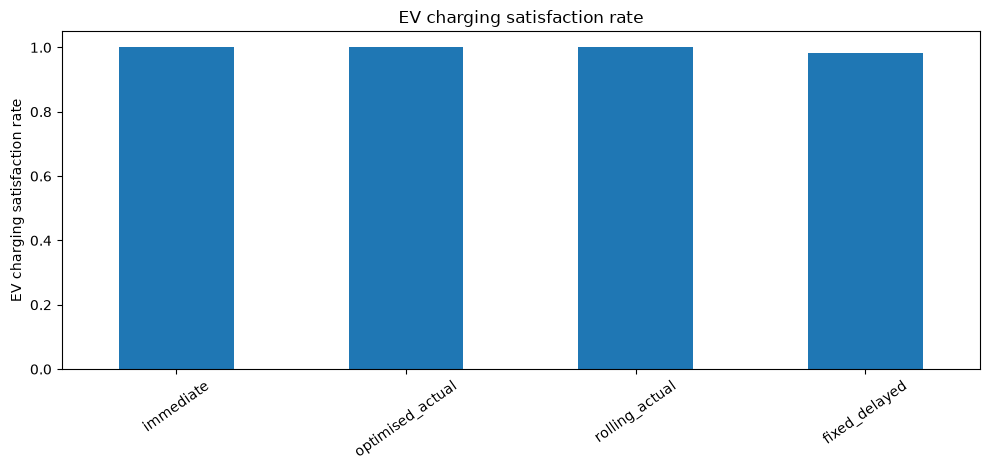

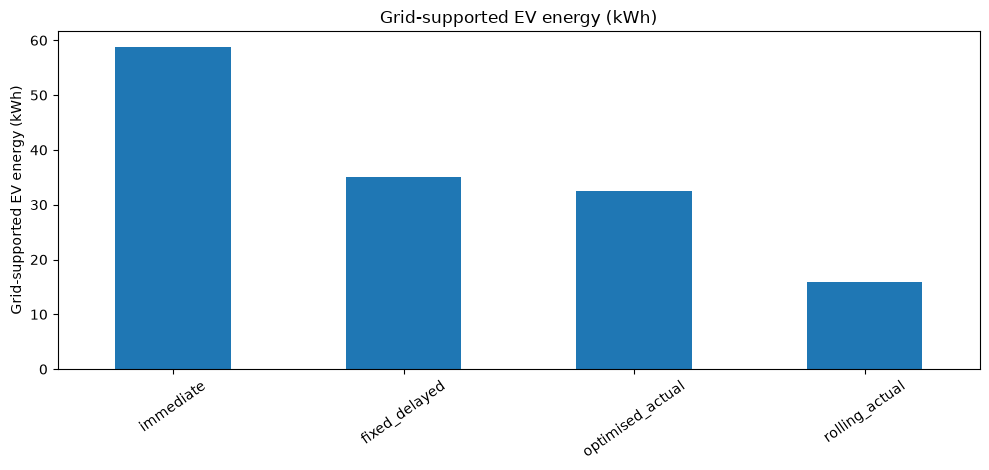

In [8]:
plot_metrics = [
    ("renewable_absorbed_kwh", "Renewable energy absorbed by EVs (kWh)", "final_renewable_absorption.png"),
    ("residual_surplus_kwh", "Residual potential surplus (kWh)", "final_residual_surplus.png"),
    ("service_rate", "EV charging satisfaction rate", "final_service_rate.png"),
    ("ev_grid_energy_kwh", "Grid-supported EV energy (kWh)", "final_grid_energy.png"),
]

for metric, ylabel, filename in plot_metrics:
    if metric not in operational.columns:
        continue
    means = operational.groupby("strategy")[metric].mean().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10, 4.8))
    means.plot(kind="bar", ax=ax)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.set_title(ylabel)
    ax.tick_params(axis="x", rotation=35)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / filename, dpi=200, bbox_inches="tight")
    plt.show()

## 7. Compact final table

In [9]:
final_table = (
    operational.groupby("strategy", as_index=False)
    .agg(
        scenarios=("scenario_id", "nunique"),
        service_rate=("service_rate", "mean"),
        renewable_absorbed_kwh=("renewable_absorbed_kwh", "mean"),
        residual_surplus_kwh=("residual_surplus_kwh", "mean"),
        ev_grid_energy_kwh=("ev_grid_energy_kwh", "mean"),
        unserved_energy_kwh=("unserved_energy_kwh", "mean"),
        peak_ev_kw=("peak_ev_kw", "mean"),
    )
    .sort_values("renewable_absorbed_kwh", ascending=False)
)
for column in final_table.select_dtypes(include="number").columns:
    final_table[column] = final_table[column].round(3)

display(final_table)
save_table(final_table, RESULTS_DIR / "final_operational_metrics.csv")

,strategy,scenarios,service_rate,renewable_absorbed_kwh,residual_surplus_kwh,ev_grid_energy_kwh,unserved_energy_kwh,peak_ev_kw
2,optimised_actual,24,1.000,584.140,12111.464,32.484,0.000,80.275
0,fixed_delayed,24,0.981,159.460,12536.144,35.096,0.098,73.000
1,immediate,24,1.000,136.035,12559.570,58.703,0.000,38.601
3,rolling_actual,6,1.000,37.377,12603.593,15.877,0.000,15.400


Saved: Data/Results/final_operational_metrics.csv


PosixPath('/Users/mac/Send-Ev-Project/SEND-EV-Project/Data/Results/final_operational_metrics.csv')

## Reporting checklist

- Show how many scenarios are included in each mean.
- Keep perfect-information results separate from forecast-based results.
- Call the surplus value a potential renewable-surplus proxy unless curtailment data is available.
- Report unmet energy as well as renewable absorption.
- Describe ACN sessions as synthetic Keele scenario inputs, not Keele user observations.